In [1]:
import sys, os, torch, random
import numpy as np
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import DataLoader
from omegaconf import OmegaConf

warnings = __import__('warnings')
warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('../../..'))

In [2]:
from DL.models.custom_classifier_from_config import CustomClassifierFromConfig
from DL.trainers.model_trainer import ModelTrainer
from DL.data.combined_dataset import CombinedDataset
from DL.loggers.experiment_logger import ExperimentLogger
from DL.visualization.visualizer import ExperimentVisualizer

from DL.losses.gan.non_saturating import NonSaturatingLoss
from DL.losses.gan.lsgan import LSGANLoss
from DL.losses.gan.wgan import WGANLoss
from DL.losses.gan.hinge import HingeLoss

In [3]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42) # Фиксируем сид

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [5]:
exp_name = "gan_losses_comparison"
logger = ExperimentLogger(exp_name, base_dir=".")
viz = ExperimentVisualizer(logger)

In [6]:
perspective_transform = T.RandomPerspective(distortion_scale=0.5, p=0.8)

train_dataset = CombinedDataset(75000, 42, transform=perspective_transform)
test_dataset = CombinedDataset(25000, 123, transform=perspective_transform)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [7]:
def train_with_loss(loss_obj, tag: str):
    conf = OmegaConf.load('../../../DL/configs/lenet/lenet_4kb.json')
    conf.num_classes = len(train_dataset.char_to_idx)

    logger.save_config(OmegaConf.to_container(conf), filename=f"config_{tag}.json")
    logger.log(f"=== Запуск эксперимента: {tag} ===")

    model = CustomClassifierFromConfig(OmegaConf.to_container(conf)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

    trainer = ModelTrainer(
        model=model, optimizer=optimizer, criterion=nn.CrossEntropyLoss(), device=device,
        use_background_loss=True, bg_loss_alpha=5.0, bg_loss_n=2,
        gan_loss_fn=loss_obj,
        logger=logger, visualizer=viz, model_name=tag
    )

    trainer.fit(train_loader, test_loader, epochs=10)
    return model

In [8]:
losses_to_test = {
    "Non_Saturating_BCE": NonSaturatingLoss(),
    "Least_Squares_MSE": LSGANLoss(),
    "Wasserstein_WGAN": WGANLoss(clip_value=0.01),
    "Hinge_Loss": HingeLoss()
}

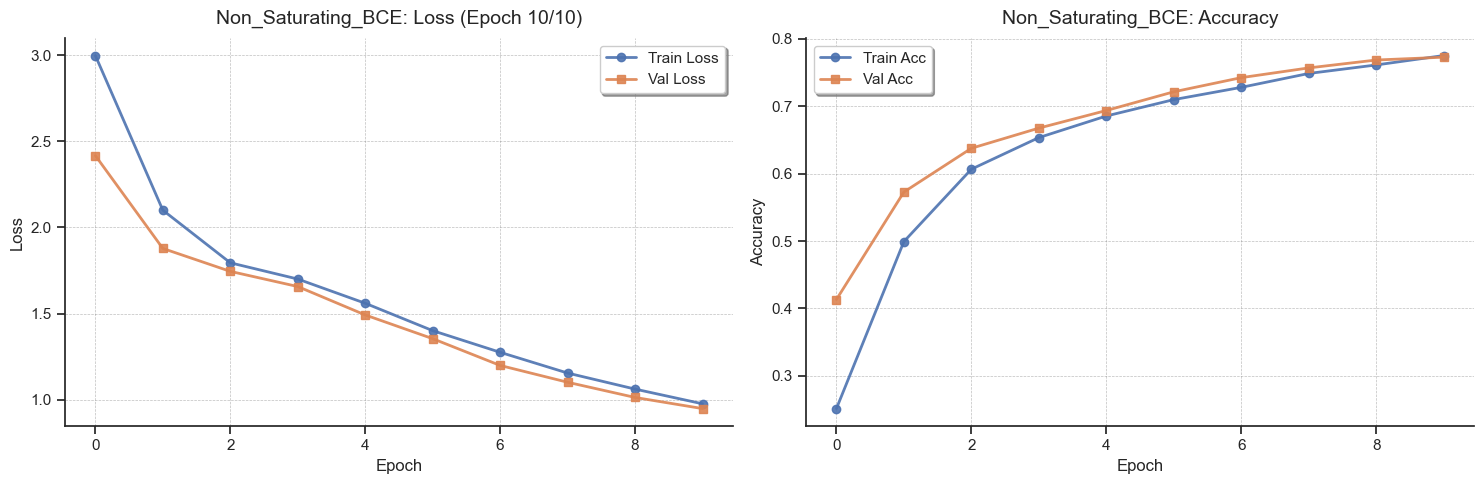

In [9]:
model_ns = train_with_loss(NonSaturatingLoss(), tag="Non_Saturating_BCE")

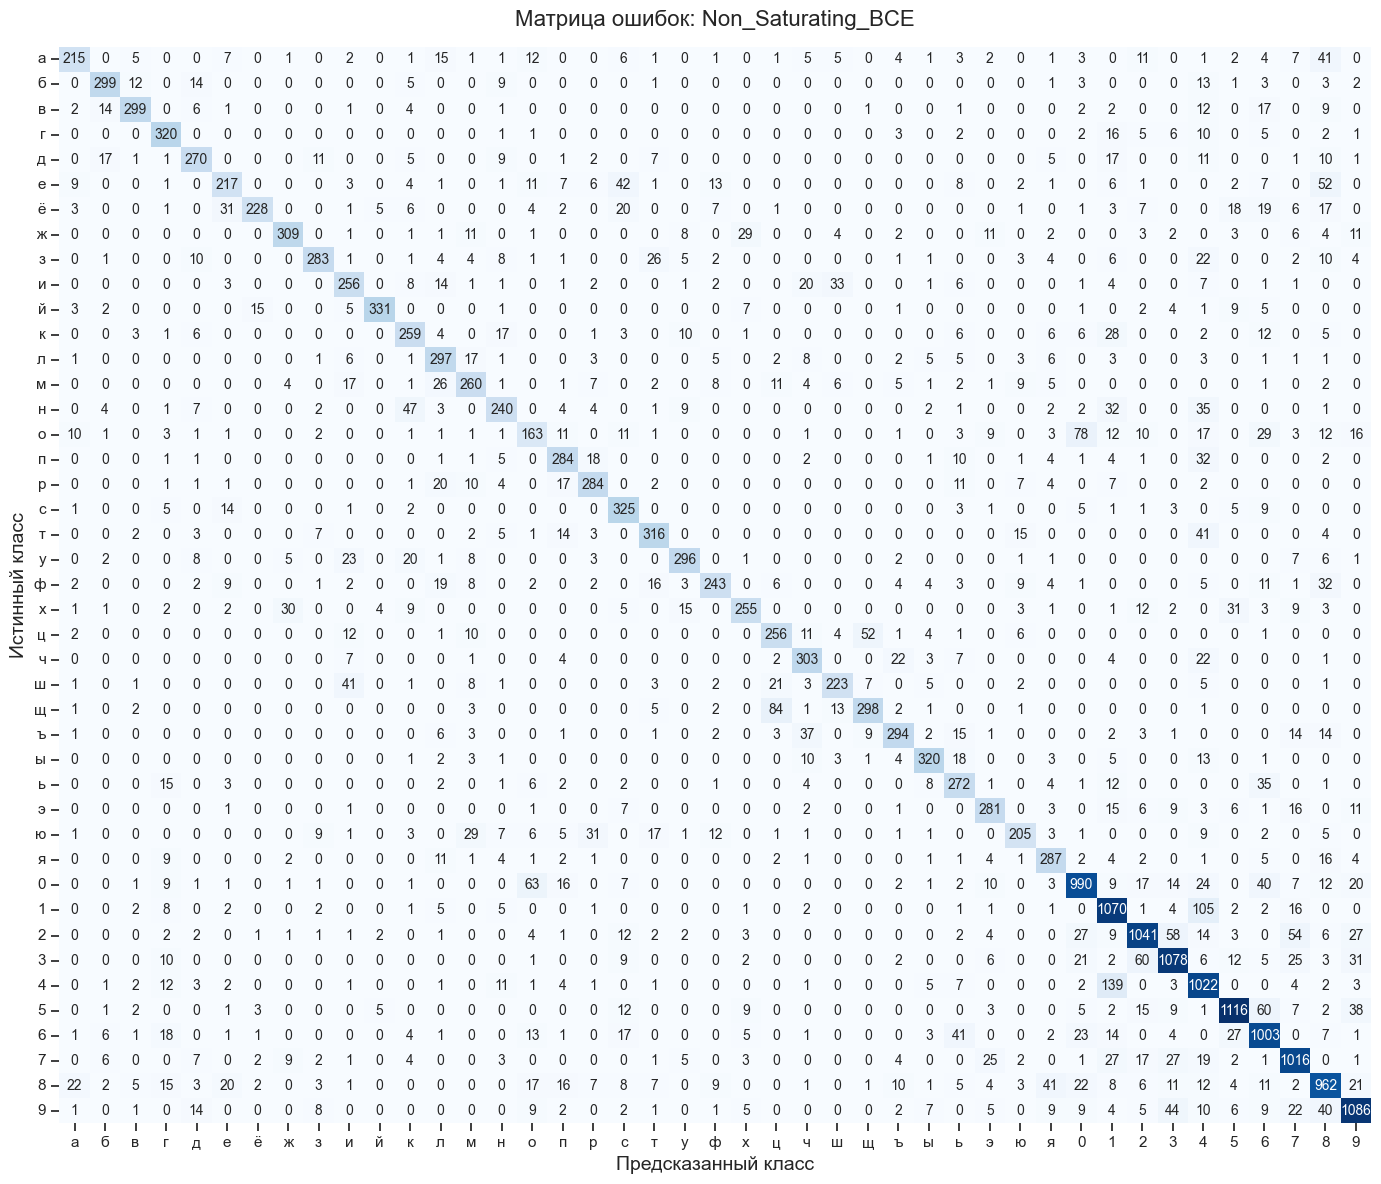

In [10]:
viz.plot_confusion_matrix(model_ns, test_loader, test_dataset, device, model_name="Non_Saturating_BCE")

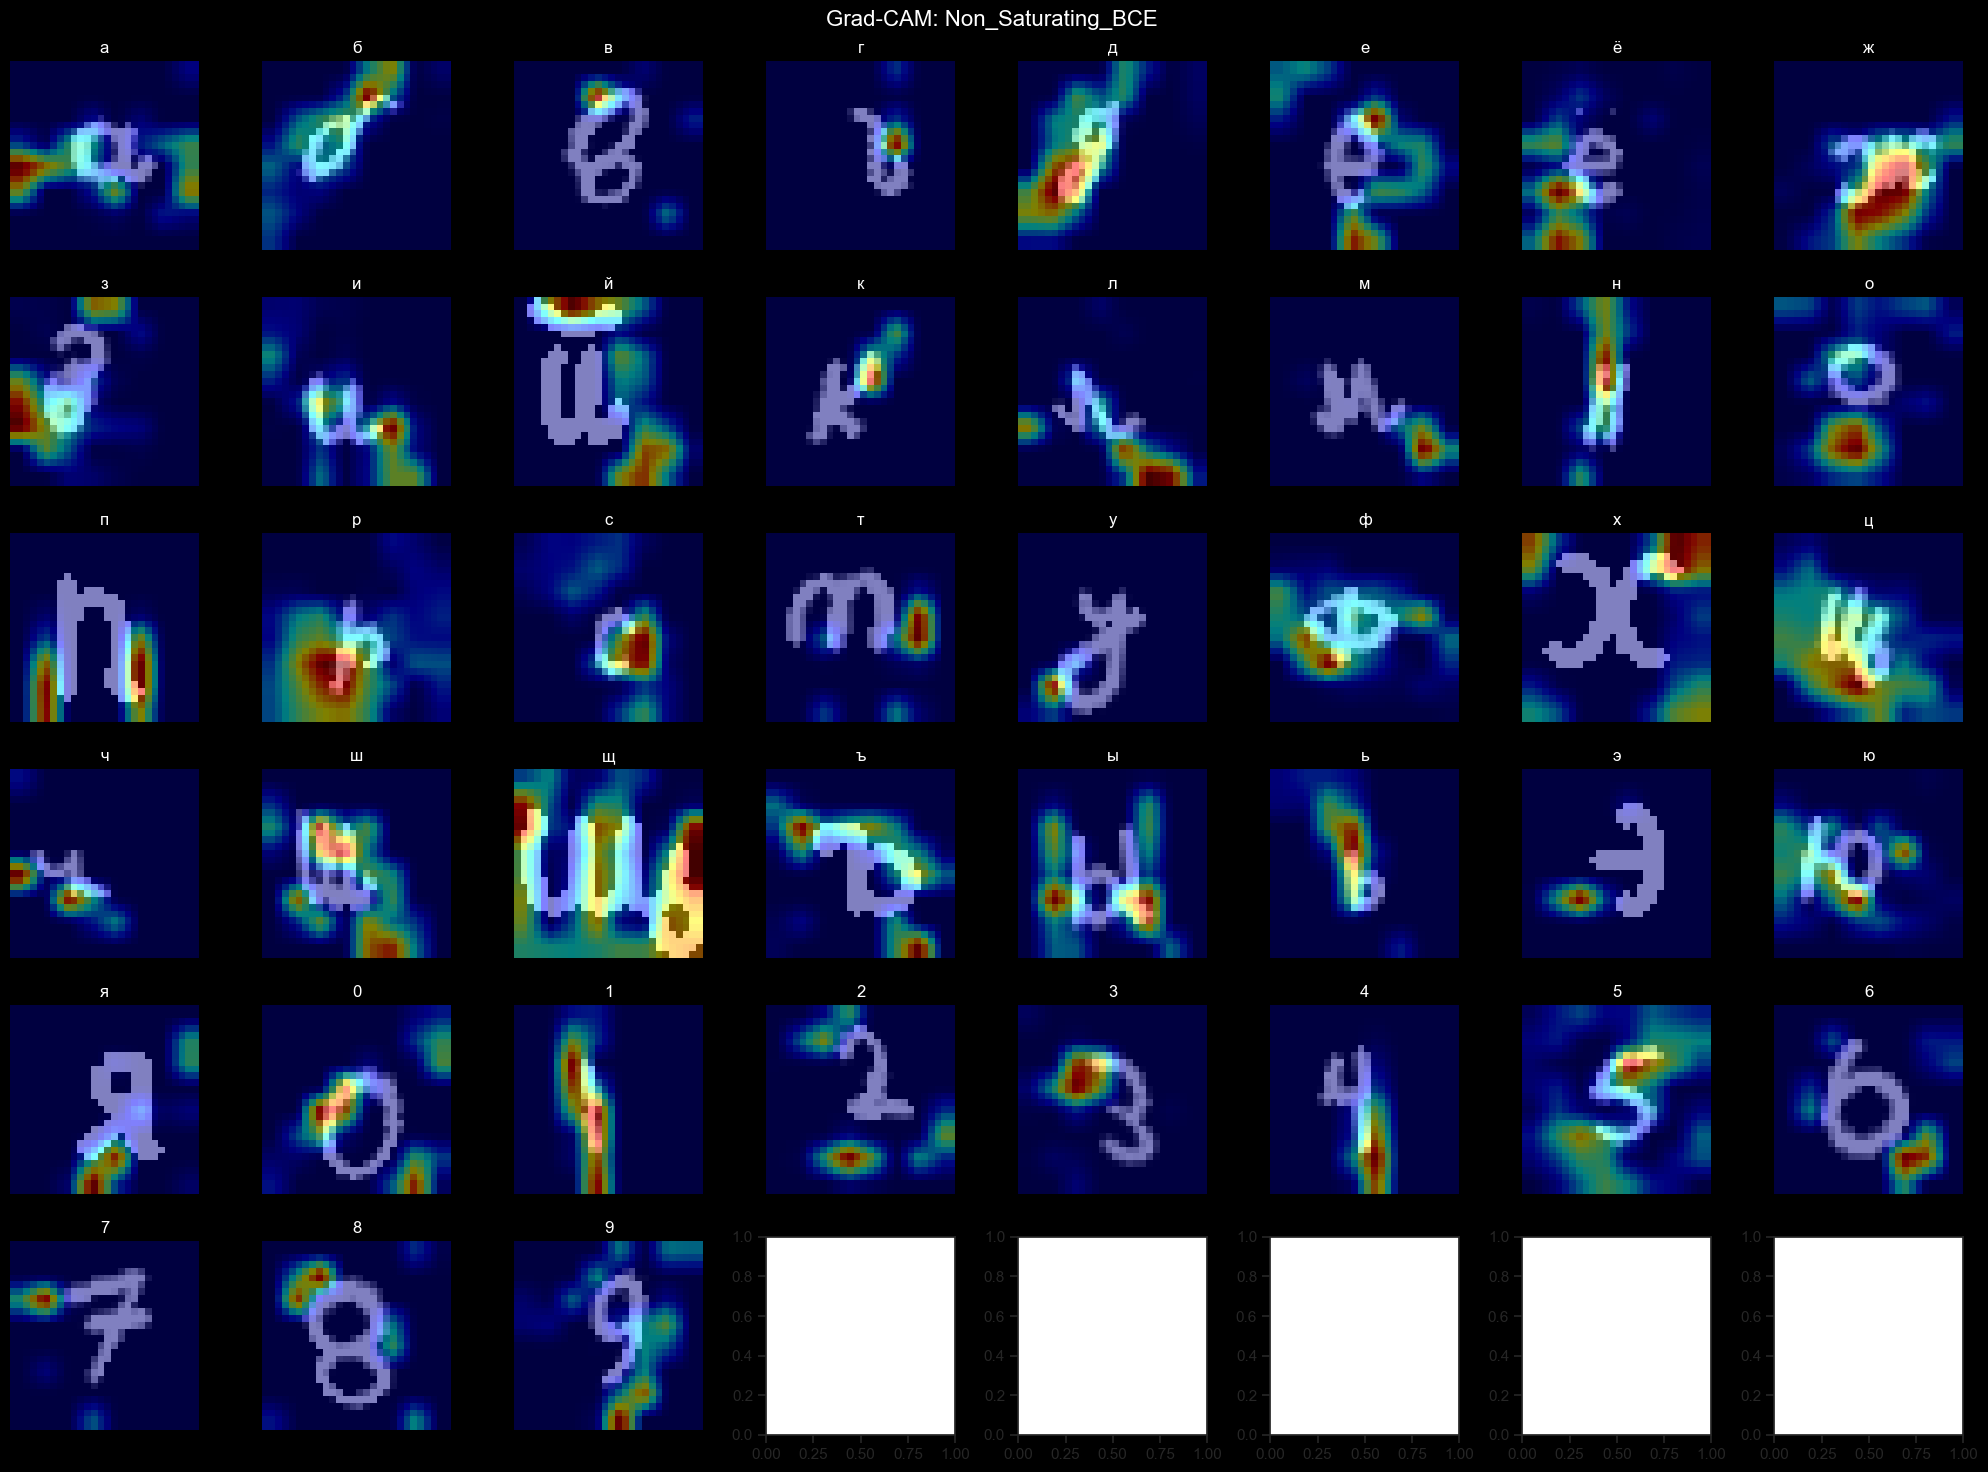

<Figure size 640x480 with 0 Axes>

In [11]:
viz.plot_gradcam(model_ns, test_dataset, device, model_name="Non_Saturating_BCE")

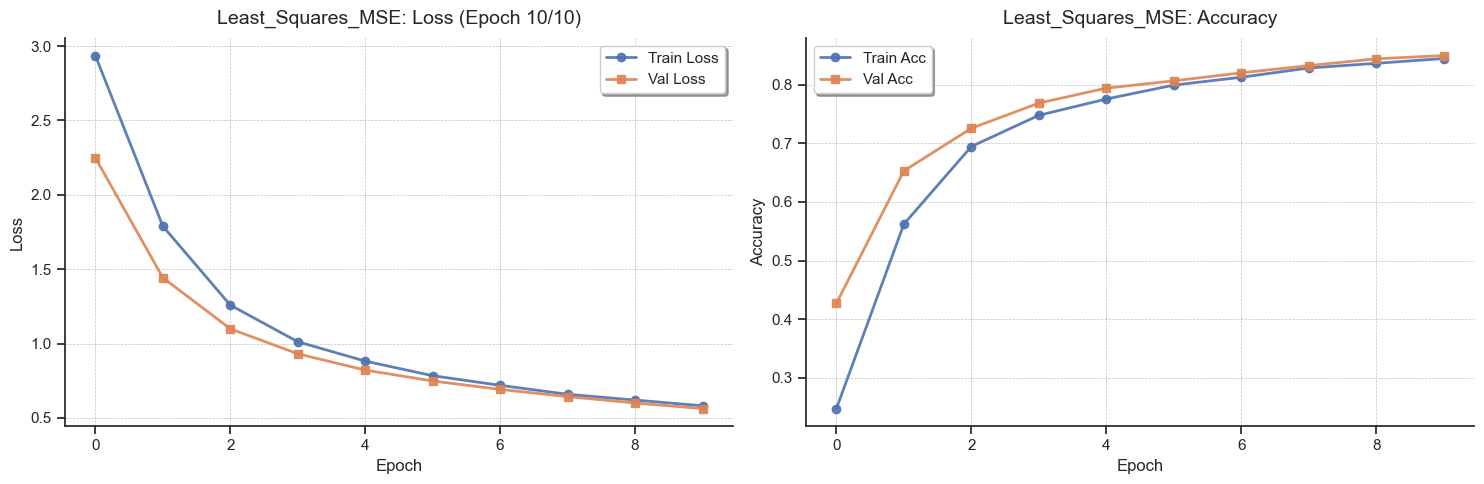

In [12]:
model_ls = train_with_loss(LSGANLoss(), tag="Least_Squares_MSE")

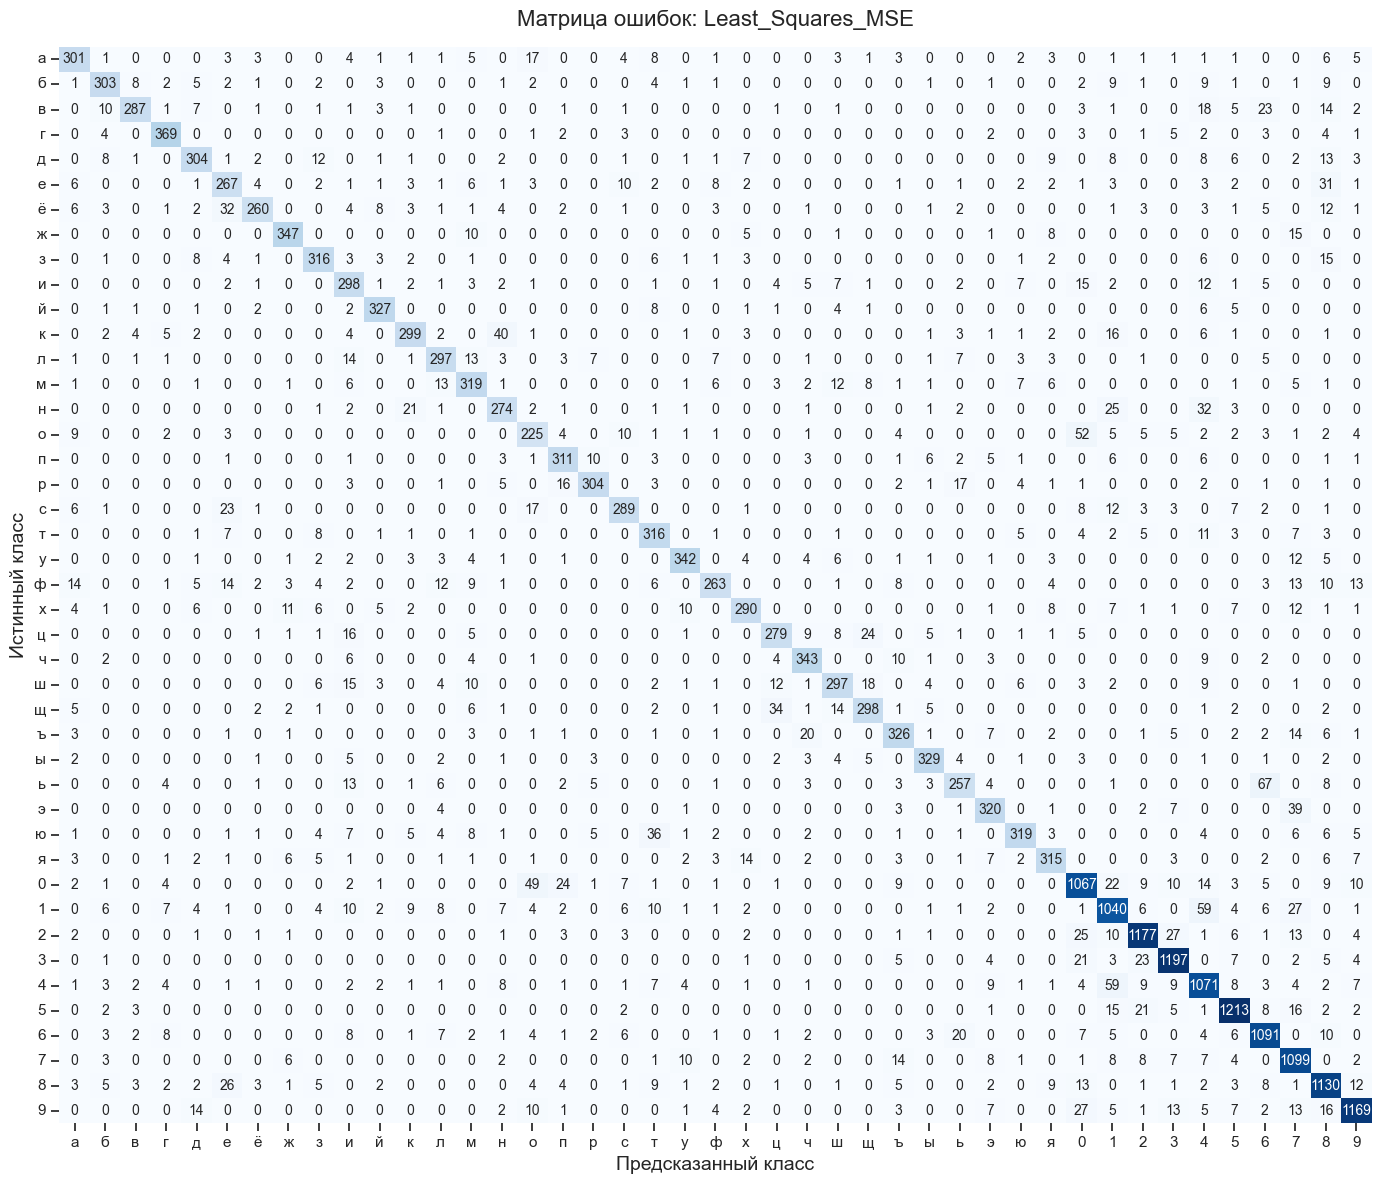

In [13]:
viz.plot_confusion_matrix(model_ls, test_loader, test_dataset, device, model_name="Least_Squares_MSE")

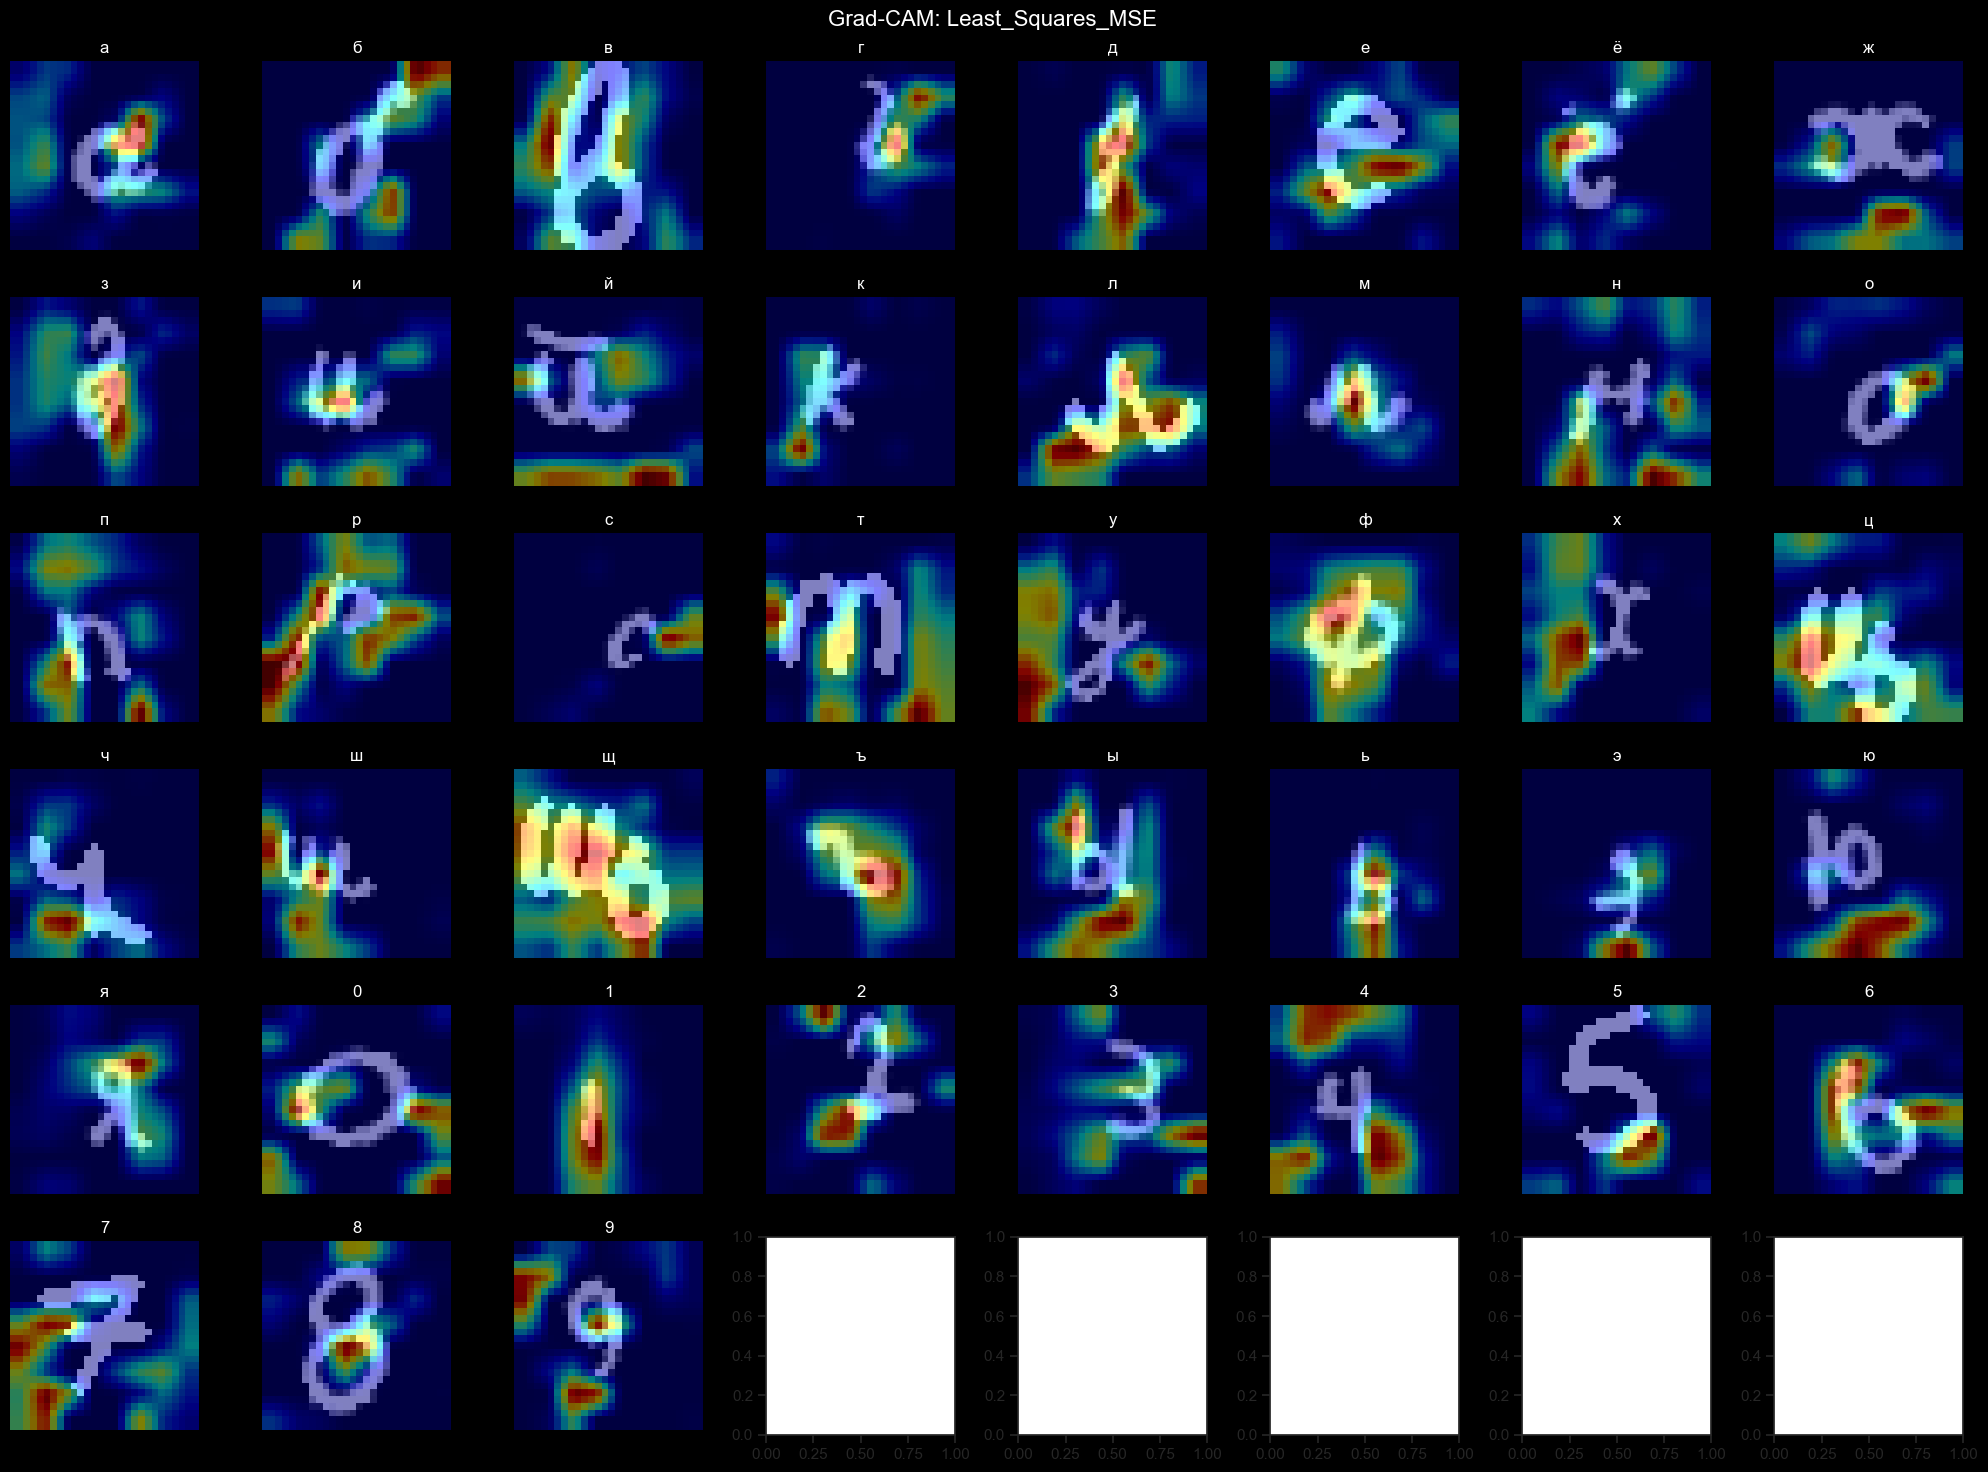

<Figure size 640x480 with 0 Axes>

In [14]:
viz.plot_gradcam(model_ls, test_dataset, device, model_name="Least_Squares_MSE")

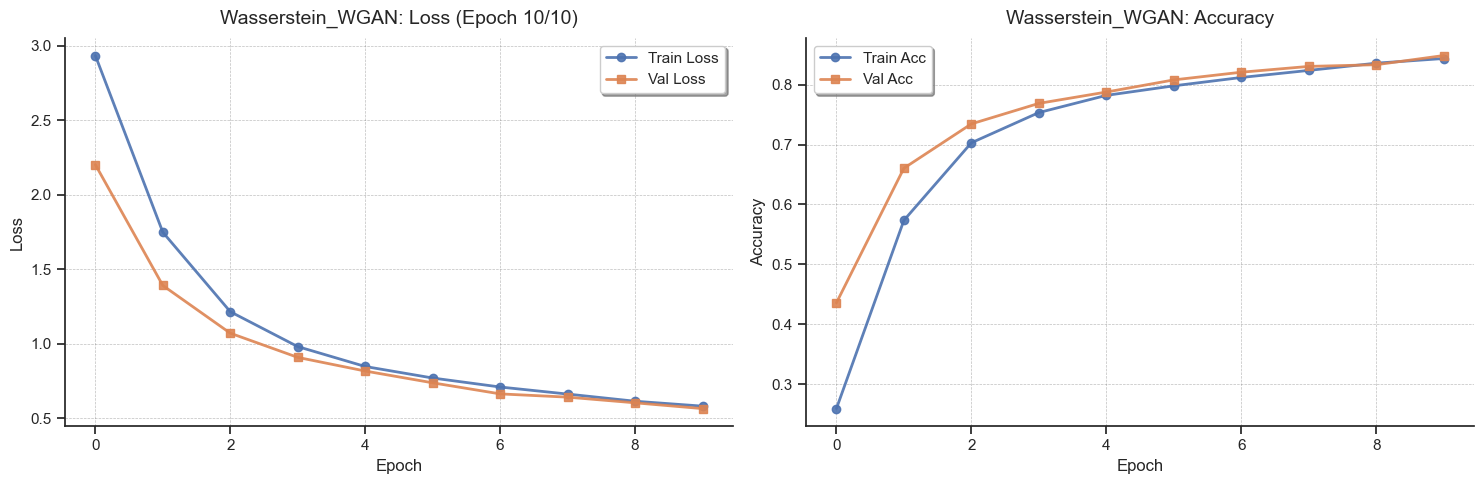

In [15]:
model_wgan = train_with_loss(WGANLoss(clip_value=0.01), tag="Wasserstein_WGAN")

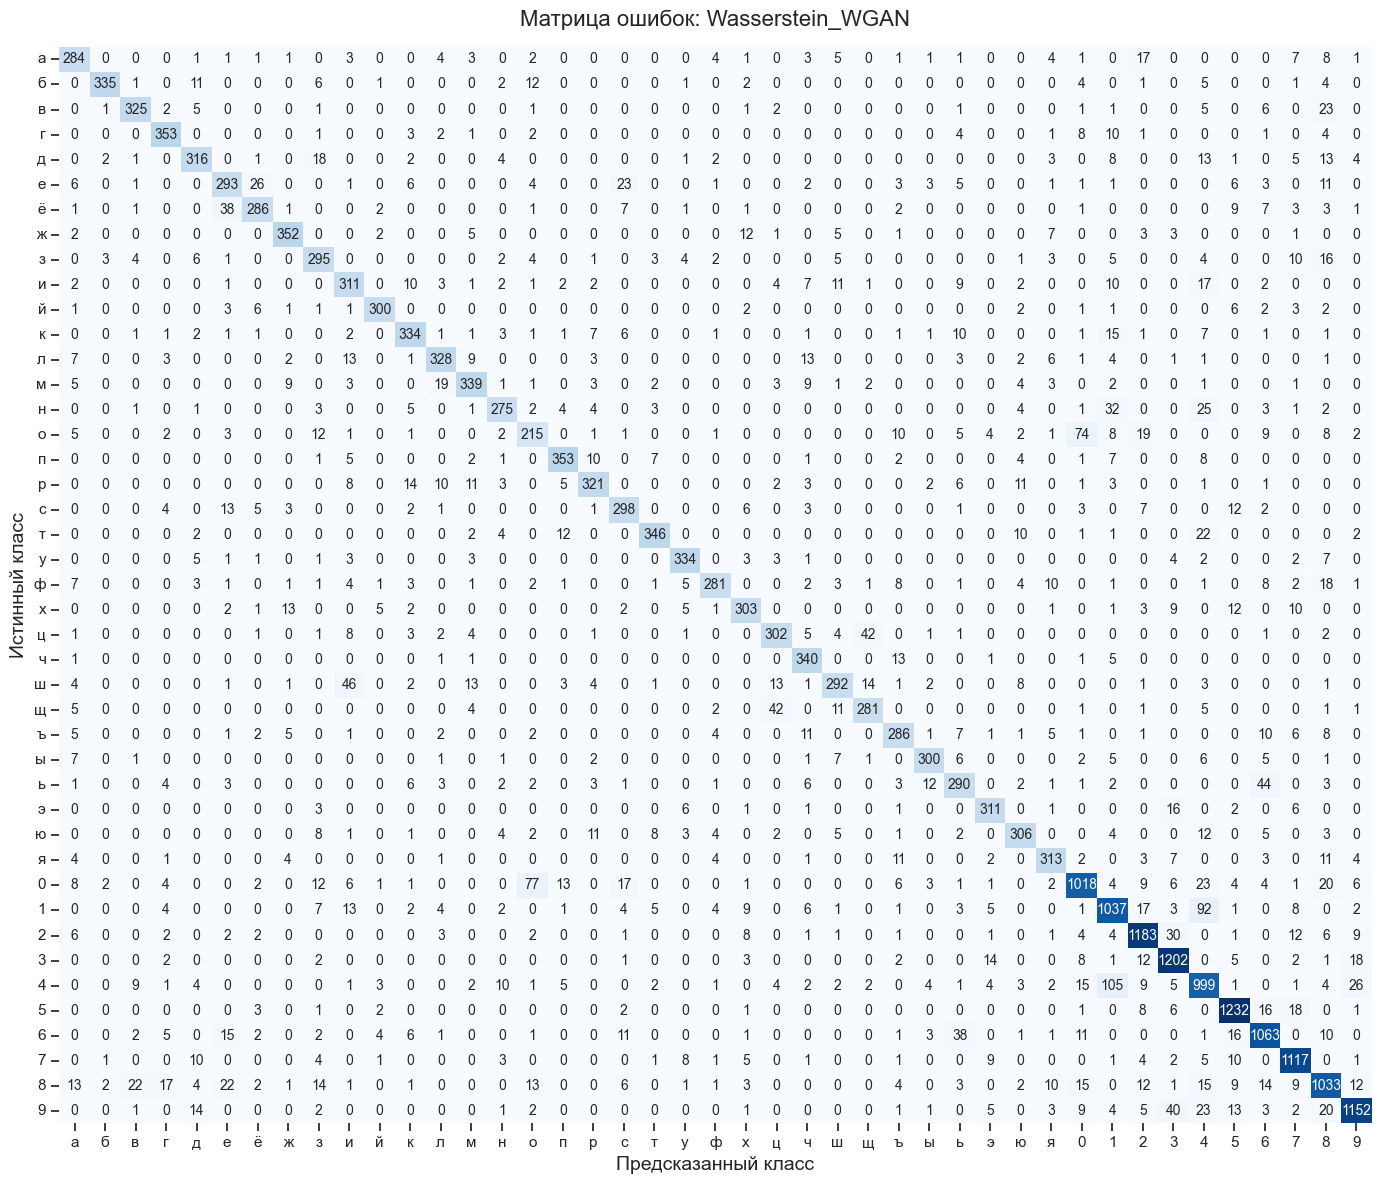

In [16]:
viz.plot_confusion_matrix(model_wgan, test_loader, test_dataset, device, model_name="Wasserstein_WGAN")

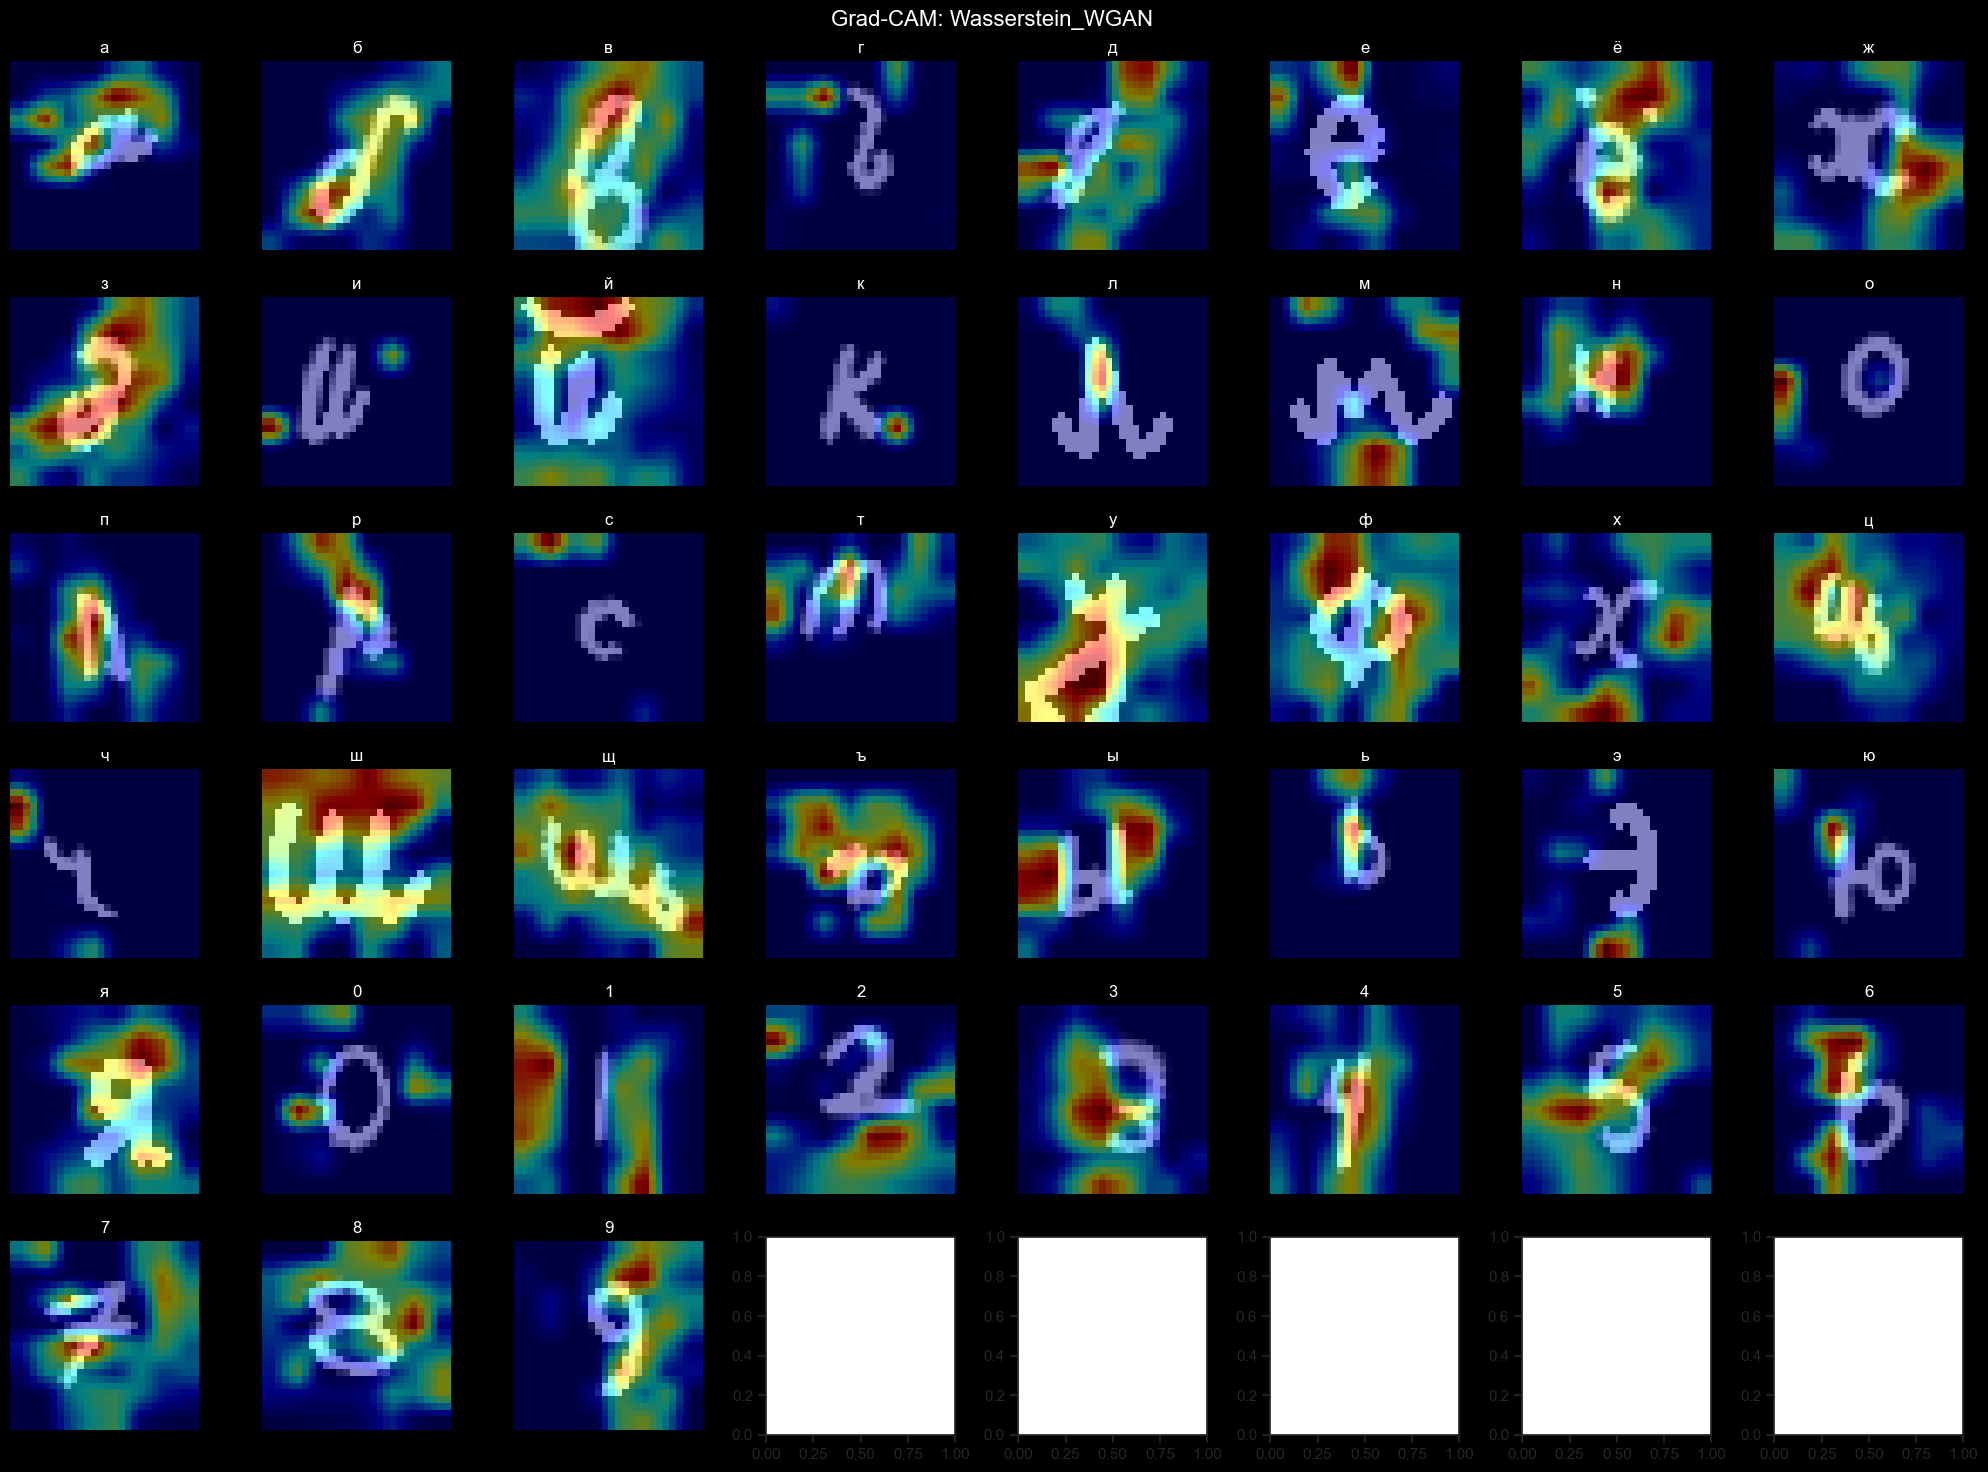

<Figure size 640x480 with 0 Axes>

In [17]:
viz.plot_gradcam(model_wgan, test_dataset, device, model_name="Wasserstein_WGAN")

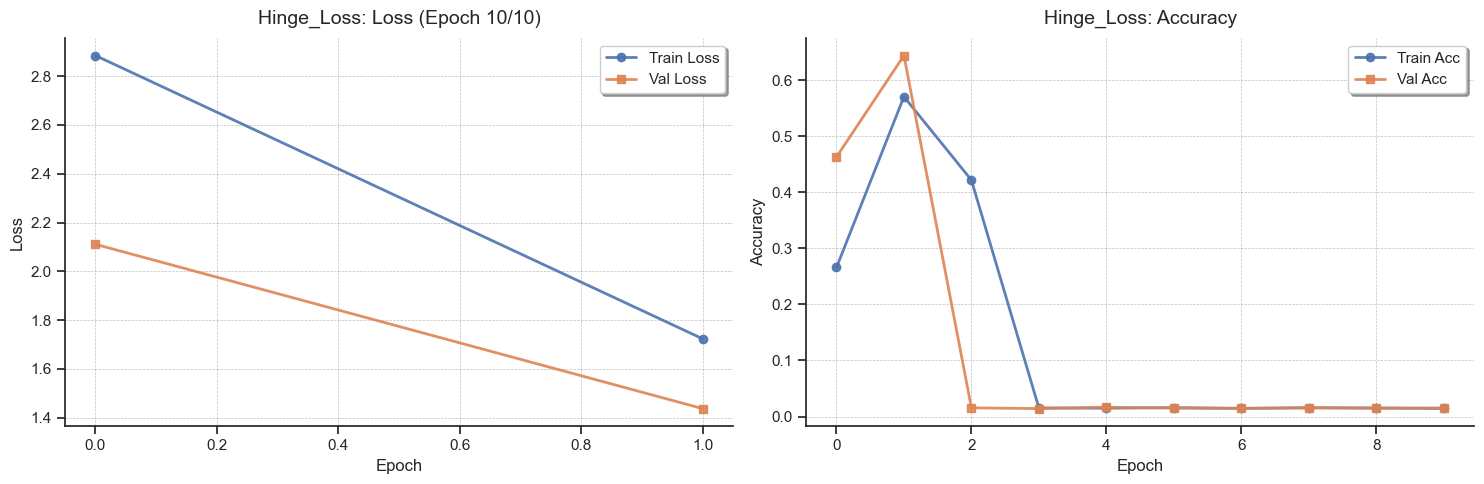

In [18]:
model_hinge = train_with_loss(HingeLoss(), tag="Hinge_Loss")

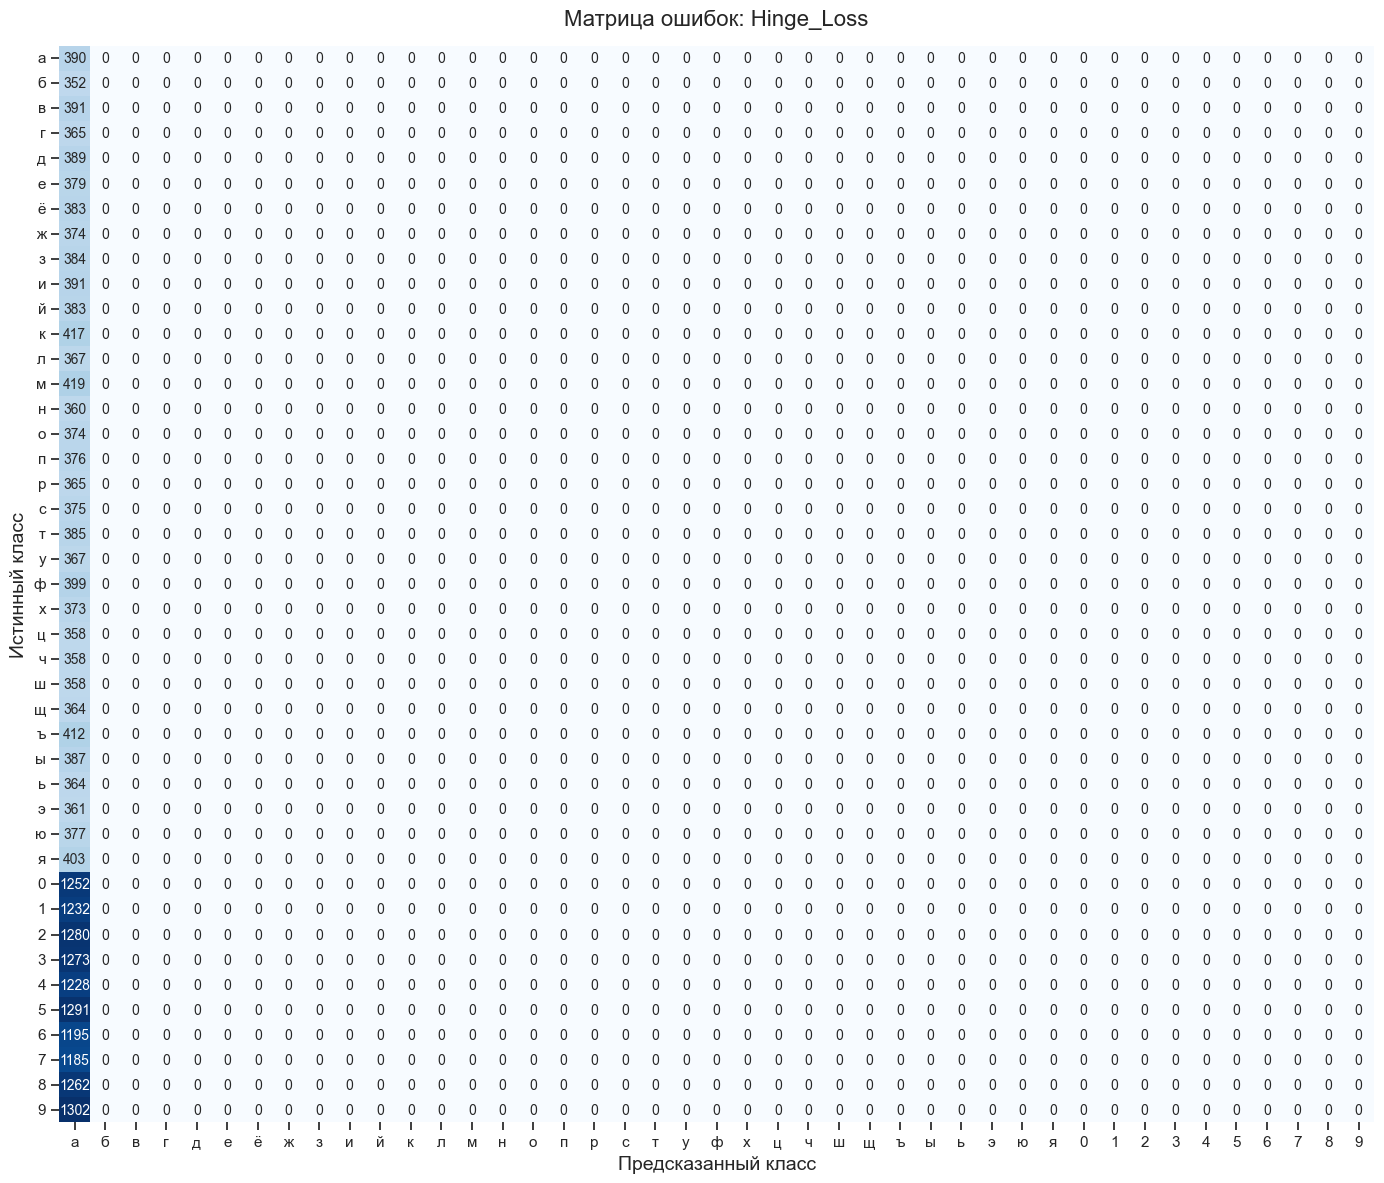

In [19]:
viz.plot_confusion_matrix(model_hinge, test_loader, test_dataset, device, model_name="Hinge_Loss")

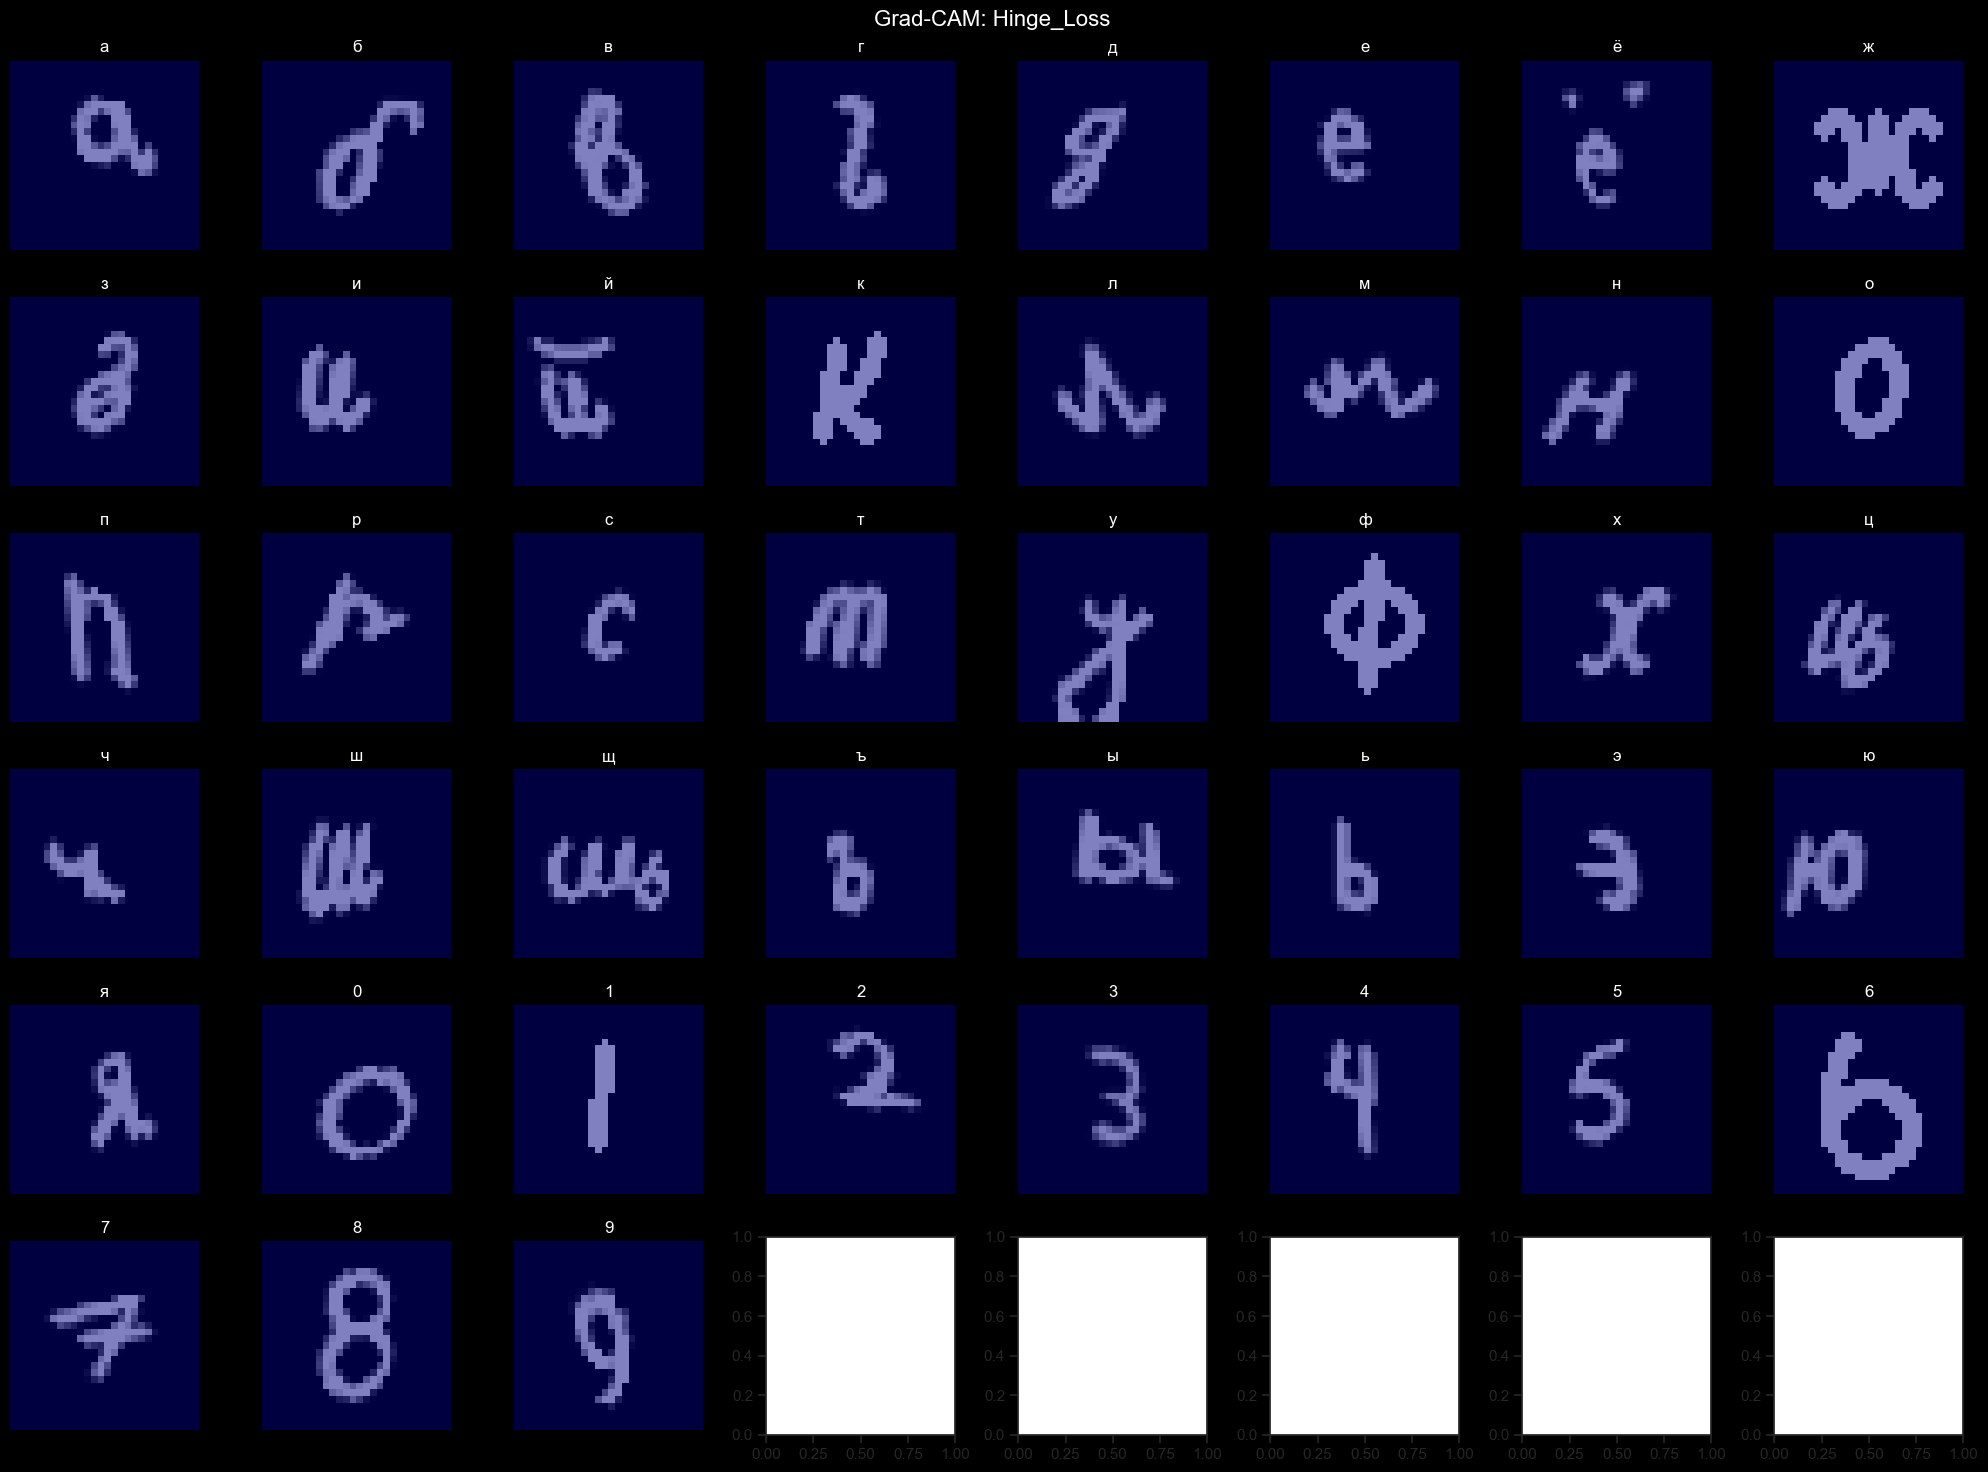

<Figure size 640x480 with 0 Axes>

In [20]:
viz.plot_gradcam(model_hinge, test_dataset, device, model_name="Hinge_Loss")